# **Proyecto ML - Parte 1:**
Jose Manuel Fonseca -202122456\
Julian Pinto - \
Daniel Vergara - 

## Contexto y objetivo

En este proyecto vamos a clasificar reseñas de productos en español como positivas, negativas o neutrales. Algunas reseñas mezclan cosas buenas y malas del producto, por lo que no siempre es fácil identificar la opinión general.

Tenemos 12.000 reseñas con etiqueta para entrenar y evaluar el modelo, y 3.000 sin etiqueta para generar las predicciones que enviaremos a Kaggle.

Para esta primera parte usaremos TF-IDF y modelos clásicos de scikit-learn. Empezaremos con un modelo sencillo y probaremos si tener en cuenta la parte final de las reseñas ayuda a mejorar los resultados.

La métrica principal será accuracy, que mide la proporción de reseñas clasificadas correctamente. También revisaremos los errores para entender en qué casos falla el modelo.

## Imports

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)
RANDOM_STATE = 42
import sys
import platform
import time
import hashlib
import joblib
import sklearn
import scipy
from IPython.display import display
from sklearn.metrics import f1_score, confusion_matrix
from threadpoolctl import threadpool_limits

np.random.seed(RANDOM_STATE)


### Reproducibilidad

Ejecutamos las celdas en orden, con los tres CSV junto al notebook. Registramos las versiones y usamos semilla 42. La comparación principal usa cinco particiones iguales; stacking y calibración tienen particiones internas. El entrenamiento completo puede tardar varios minutos.

Para cargar el modelo en otra sesión se necesitan estas mismas versiones y ejecutar antes los imports y las definiciones de clases y funciones del notebook.


In [2]:
versiones = {
    "Python": platform.python_version(),
    "scikit-learn": sklearn.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "joblib": joblib.__version__,
}
display(pd.DataFrame(versiones.items(), columns=["Librería", "Versión"]))

huellas_datos = {
    nombre: hashlib.sha256(Path(nombre).read_bytes()).hexdigest()
    for nombre in ["train.csv", "eval.csv", "sample_submission.csv"]
}


,Librería,Versión
0,Python,3.12.13
1,scikit-learn,1.9.1
2,numpy,2.5.3
3,pandas,3.0.6
4,scipy,1.18.1
5,joblib,1.6.0


## Carga de datos

Cargamos train.csv, que contiene texto y etiqueta, y eval.csv, que no tiene etiquetas. Este último se usará para generar el envío a Kaggle.


In [3]:
train = pd.read_csv("train.csv")
eval_df = pd.read_csv("eval.csv")

print("train:", train.shape)
print("eval:", eval_df.shape)
train.head()

train: (12000, 3)
eval: (3000, 2)


,id,text,label
0,0,"Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo más de medio kilo. Lo tengo en el escritorio del trabajo y por ahora nomás lo uso de vez en cuando. Viene con su cable y el manual en la caja.",neutral
1,1,"Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea dicha, el soporte técnico me resultó incumplidor para lo que necesitaba, tardaban harto en contestar. Al final de cuentas, la nitidez de la imagen se mantuvo decente en el uso diario.",positivo
2,2,"Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficina casi a diario desde entonces. El diseño se sintió durable desde el primer día. Aun así, la relación calidad-precio se ve desagradable con el tiempo.",negativo
3,3,"Compré esto en línea y llegó en unos tres días a la casa. Venían varias unidades en el paquete, revisé todas una por una. El ensamblaje terminó siendo impreciso para lo que necesitaba, la verdad. Lo probé el fin de semana mientras armaba el espacio donde lo iba a poner.",negativo
4,4,"Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. La verdad, el cargador me pareció terrible para mi gusto. Lo uso casi todos los días en la oficina y ya le agarré la práctica, aunque mis compañeros se ríen de lo desordenado que tengo el escritorio. El micrófono me pareció decente para ser honesto.",positivo


## Exploración de los datos

### Calidad y distribución de clases

Revisamos valores faltantes, duplicados y la cantidad de reseñas de cada etiqueta.


Valores nulos por columna
Textos duplicados
Distribución de clases


,train,eval
id,0,0.0
label,0,No aplica
text,0,0.0


,train,eval
Duplicados,0,0


,Cantidad,Porcentaje
Etiqueta,,
positivo,4212,35.1
negativo,4212,35.1
neutral,3576,29.8


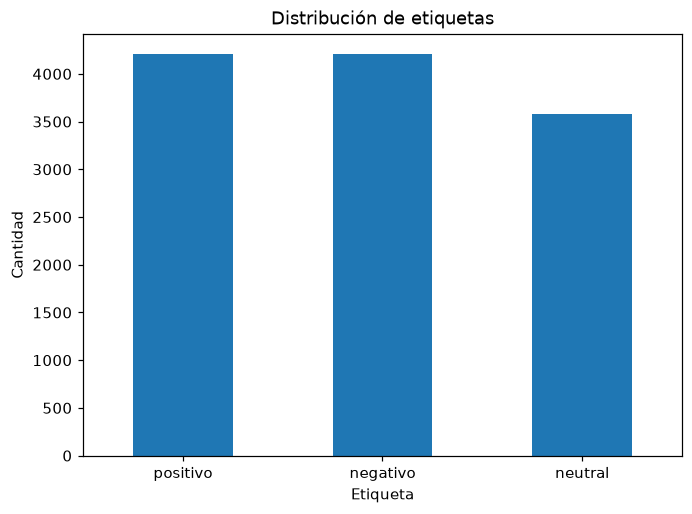

In [4]:
print("Valores nulos por columna")
display(pd.DataFrame({
    "train": train.isna().sum(),
    "eval": eval_df.isna().sum(),
}).fillna("No aplica"))

print("Textos duplicados")
display(pd.DataFrame({
    "train": [train["text"].duplicated().sum()],
    "eval": [eval_df["text"].duplicated().sum()],
}, index=["Duplicados"]))

conteos = train["label"].value_counts()

print("Distribución de clases")
display(pd.DataFrame({
    "Cantidad": conteos,
    "Porcentaje": (conteos / len(train) * 100).round(2),
}).rename_axis("Etiqueta"))

conteos.plot(
    kind="bar",
    title="Distribución de etiquetas",
    ylabel="Cantidad",
    xlabel="Etiqueta",
    rot=0,
)
plt.show()

Las clases están relativamente equilibradas: positivo y negativo tienen 4.212 reseñas cada una (35,1 %), y neutral tiene 3.576 (29,8 %). Empezaremos sin pesos especiales por clase y evaluaremos si cambiarlos mejora los resultados.

### Textos vacíos e identificadores


In [5]:
revision = pd.DataFrame({
    "train": [
        train["text"].str.strip().eq("").sum(),
        train["id"].isna().sum(),
        train["id"].duplicated().sum(),
    ],
    "eval": [
        eval_df["text"].str.strip().eq("").sum(),
        eval_df["id"].isna().sum(),
        eval_df["id"].duplicated().sum(),
    ],
}, index=[
    "Textos vacíos o con solo espacios",
    "Identificadores nulos",
    "Identificadores repetidos",
])

display(revision)

,train,eval
Textos vacíos o con solo espacios,0,0
Identificadores nulos,0,0
Identificadores repetidos,0,0


In [6]:
assert set(train.columns) == {"id", "text", "label"}
assert set(eval_df.columns) == {"id", "text"}
assert train["label"].isin(["negativo", "neutral", "positivo"]).all()
assert train["text"].map(lambda texto: isinstance(texto, str)).all()
assert eval_df["text"].map(lambda texto: isinstance(texto, str)).all()
assert not train.isna().any().any()
assert not eval_df.isna().any().any()

display(pd.DataFrame({
    "Cantidad": [
        len(set(train["text"]) & set(eval_df["text"])),
        train["text"].str.lower().str.strip().duplicated().sum(),
    ],
}, index=["Textos exactos compartidos entre train y eval",
          "Repetidos en train tras minúsculas y espacios"]))


,Cantidad
Textos exactos compartidos entre train y eval,0
Repetidos en train tras minúsculas y espacios,0


No encontramos valores faltantes, textos vacíos ni textos o identificadores repetidos dentro de cada archivo. No necesitamos eliminar filas ni completar valores.


### Ejemplos por clase

Leemos tres reseñas por clase para entender su contenido. Son ejemplos para proponer ideas, no conclusiones sobre todos los datos.


In [7]:
for etiqueta in ["positivo", "negativo", "neutral"]:
    print(f"\n--- {etiqueta.upper()} ---")

    ejemplos = train.loc[
        train["label"] == etiqueta, "text"
    ].sample(3, random_state=RANDOM_STATE)

    for numero, texto in enumerate(ejemplos, start=1):
        print(f"\n{numero}. {texto}")


--- POSITIVO ---

1. Me llegó el equipo a casa en tres días, lo pedí un martes por la noche y ya estaba probándolo el viernes. Después de usarlo bastante, lo pruebo casi todos los días, más que nada en las tardes después del trabajo. Para mí, el rendimiento me resultó ser mal terminado en el uso real. Lo tengo conectado en el escritorio del cuarto, con el cargador original de 65W. Sin embargo, el procesador se mantuvo espectacular en el uso real.

2. La compré hace un par de meses por internet y llegó en tres días a mi casa. Ya con un tiempo de uso, lo uso para el gimnasio, principalmente cuando voy en las tardes después del trabajo. La instalación la hizo mi cuñado un sábado en la mañana y no hubo ningún problema. Terminé feliz con la instalación.

3. Hace un par de semanas lo pedi porque lo necesitaba para el trabajo, me llego en unos tres dias a la oficina. Me alegra haber elegido la ergonomia. Lo uso todos los dias en el escritorio junto a la laptop. De paso, la app del fabricante

### Observaciones de las reseñas

En los ejemplos positivos y negativos encontramos reseñas que mezclan
elogios y críticas. Por eso, identificar palabras positivas o negativas
por separado puede no ser suficiente para clasificar la opinión general.

En algunos casos, la opinión final coincide con la etiqueta, pero también
hay ejemplos donde ocurre lo contrario. Probaremos si representar la
parte final junto con el texto completo ayuda al modelo.

Los ejemplos neutrales describen principalmente el envío, el uso y las
características del producto. También observamos textos sin tildes y
algunos errores de escritura.

### Longitud de las reseñas

Contamos las palabras separadas por espacios y comparamos las longitudes por clase.


In [8]:
longitudes = train.assign(
    palabras=train["text"].str.split().str.len()
)

display(
    longitudes.groupby("label")["palabras"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

,count,mean,median,min,max
label,,,,,
negativo,4212,54.23,54.0,6,100
neutral,3576,52.28,52.0,3,96
positivo,4212,55.00,55.0,5,110


Las reseñas de las tres clases tienen una longitud similar: el promedio
está entre 52 y 55 palabras y las medianas son cercanas. No observamos
una diferencia marcada de longitud entre las etiquetas.

## Decisiones a partir de la exploración

Conservaremos todas las filas, las negaciones y los conectores. Usaremos solo el texto como entrada; el identificador no será una característica.

Los primeros tres modelos conservan las tildes. Desde el cuarto las normalizamos para unificar variantes como "cámara" y "camara". Empezamos sin pesos especiales por clase porque las proporciones son cercanas.


### Por qué tomamos estas decisiones

| Decisión | Motivo y limitación |
|---|---|
| Accuracy y F1 por clase | Accuracy coincide con Kaggle; F1 evita ocultar dificultades de una clase. |
| Sin eliminar negaciones ni conectores | "No" y "pero" pueden cambiar el sentimiento global. |
| Palabras y caracteres | Las palabras capturan expresiones; los caracteres ayudan ante variaciones de escritura. |
| Normalizar tildes desde el cuarto intento | Unifica variantes, pero también transforma "ñ" en "n" y puede perder distinciones. |
| Sin balancear clases inicialmente | Las proporciones son cercanas; neutral se reconoce bien sin aumentar su peso. |
| TF-IDF dentro del pipeline | Cada partición aprende su vocabulario, sin usar los textos que evalúa. |
| Árboles sobre rasgos estructurales | Permiten aprender interacciones entre opinión, posición, negación y conectores. No requieren escalamiento. |
| Reserva final del 20 % | No la usamos para elegir parámetros. La exploración inicial sí revisó el archivo completo, así que no es una prueba totalmente ciega. |

Todas las predicciones las producen clasificadores clásicos de scikit-learn. Las expresiones regulares solo construyen características; no reemplazan al modelo ni usan etiquetas de eval.


## Separación de entrenamiento y validación

Usaremos el 80 % de las reseñas para entrenar y comparar los modelos.
Reservaremos el 20 % restante para evaluar el modelo elegido al final.

La separación mantendrá aproximadamente la proporción de cada clase.
Usaremos una semilla fija para poder repetirla.

In [9]:
X = train["text"]
y = train["label"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Entrenamiento:", len(X_train))
print("Validación:", len(X_valid))

Entrenamiento: 9600
Validación: 2400


## Representación con TF-IDF

TF-IDF convierte cada reseña en números y da más peso a términos frecuentes en ella, pero poco comunes en el conjunto. Aprendemos el vocabulario solo con entrenamiento, usando palabras individuales.


In [10]:
vectorizador = TfidfVectorizer()

X_train_tfidf = vectorizador.fit_transform(X_train)

print("Dimensiones:", X_train_tfidf.shape)
vectorizador.get_feature_names_out()[:20]

Dimensiones: (9600, 5504)


array(['10', '100', '10000', '110', '110v', '120', '120v', '127v', '128',
       '128gb', '14', '15', '16', '18w', '1tb', '200', '2000', '20000',
       '20w', '220'], dtype=object)

La representación tiene 9.600 filas y 5.504 términos. Los términos mostrados están ordenados alfabéticamente, no por importancia.


## Primer modelo: regresión logística

El clasificador aprende pesos para relacionar los términos con las tres etiquetas. Aunque se llama regresión, aquí se usa para clasificar. max_iter=1000 fija el límite de iteraciones del ajuste.


In [11]:
modelo = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)

modelo.fit(X_train_tfidf, y_train)
print("Modelo entrenado")

Modelo entrenado


## Validación cruzada

Usamos cinco particiones estratificadas del conjunto de entrenamiento. El Pipeline une TF-IDF y el clasificador para que cada partición aprenda su propio vocabulario sin usar las reseñas que evalúa. Las 2.400 reseñas finales siguen reservadas.

El entrenamiento anterior muestra los pasos por separado; aquí se vuelven a entrenar dentro de cada partición para medir su desempeño.


In [12]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("modelo", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

resultados = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
)

display(pd.DataFrame({
    "accuracy": resultados["test_score"]
}))

print("Accuracy promedio:", resultados["test_score"].mean())
print("Desviación estándar:", resultados["test_score"].std())

Accuracy promedio: 0.7238541666666667
Desviación estándar: 0.0159017163643845


,accuracy
0,0.734896
1,0.724479
2,0.725521
3,0.740104
4,0.694271


El modelo con TF-IDF y regresión logística obtuvo un accuracy promedio
de 72,39 % en validación cruzada. Los resultados variaron entre 69,43 %
y 74,01 %, con una desviación de 1,59 puntos porcentuales.

Este resultado será nuestra referencia para comparar las siguientes
configuraciones.

## Resultados por clase

Obtenemos una predicción para cada reseña con un modelo que no la vio durante el entrenamiento. Precision mide cuántas predicciones de una clase son correctas; recall, cuántos ejemplos reales de esa clase reconocemos; F1 combina ambas medidas. En la matriz, las filas son las etiquetas reales y las columnas las predicciones.


              precision    recall  f1-score   support

    negativo      0.623     0.604     0.613      3369
     neutral      0.956     0.995     0.975      2861
    positivo      0.616     0.614     0.615      3370

    accuracy                          0.724      9600
   macro avg      0.732     0.737     0.734      9600
weighted avg      0.720     0.724     0.722      9600



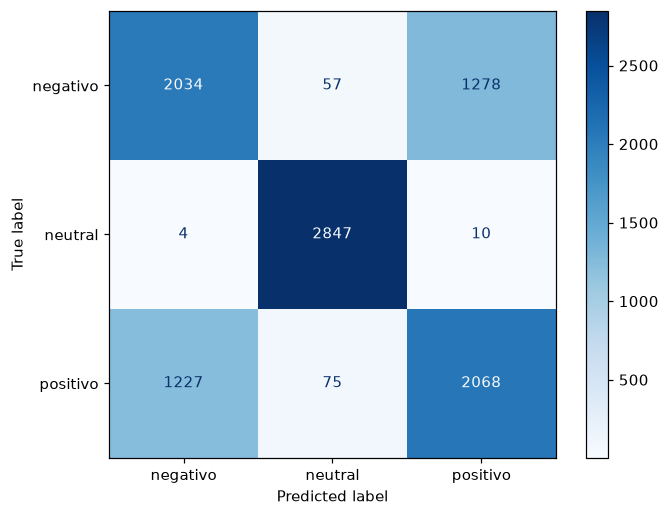

In [13]:
predicciones_cv = cross_val_predict(
    pipeline,
    X_train,
    y_train,
    cv=cv,
)

print(classification_report(
    y_train,
    predicciones_cv,
    digits=3,
))

ConfusionMatrixDisplay.from_predictions(
    y_train,
    predicciones_cv,
    labels=["negativo", "neutral", "positivo"],
    cmap="Blues",
)
plt.show()

El modelo reconoce el 99,5 % de las reseñas neutrales, pero solo el 60,4 % de las negativas y el 61,4 % de las positivas. Las siguientes pruebas buscarán mejorar la distinción de estas clases.


El primer envío obtuvo un score público de 0.72333 (72,33 %), cercano al 72,39 % de validación cruzada. Son resultados de conjuntos distintos.


## Segundo intento: TF-IDF con bigramas

Agregamos pares de palabras consecutivas, como "no funciona" o "muy bueno", además de las palabras individuales. Conservamos la regresión logística y las mismas particiones para medir el efecto de este cambio. Las 2.400 reseñas finales siguen reservadas durante la comparación.


In [14]:
pipeline_bigramas = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2))),
    ("modelo", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

resultados_bigramas = cross_validate(
    pipeline_bigramas,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
)

display(pd.DataFrame({
    "primer_modelo": resultados["test_score"],
    "con_bigramas": resultados_bigramas["test_score"],
}))

print("Accuracy promedio:", resultados_bigramas["test_score"].mean())
print("Desviación estándar:", resultados_bigramas["test_score"].std())


Accuracy promedio: 0.7232291666666667
Desviación estándar: 0.016256675979082858


,primer_modelo,con_bigramas
0,0.734896,0.723958
1,0.724479,0.730208
2,0.725521,0.725000
3,0.740104,0.743229
4,0.694271,0.693750


Los bigramas obtuvieron 72,32 % de accuracy promedio, frente al 72,39 % del primer modelo. Mejoraron en dos particiones, pero no aportaron una mejora consistente. En Kaggle obtuvieron 0.72777, frente al 0.72333 del primero; los resultados locales y públicos corresponden a conjuntos distintos.


## Tercer intento: texto completo y última oración

Combinamos dos TF-IDF: uno del texto completo y otro de la última oración. La extracción separa por puntos, signos de pregunta, exclamación y punto y coma. Conservamos el texto completo porque la opinión final no siempre determina la etiqueta.

FeatureUnion une ambas representaciones. Mantenemos palabras individuales, la misma regresión logística y las mismas cinco particiones; lo nuevo es distinguir qué términos aparecen al final.


In [15]:
def extraer_ultima_oracion(textos):
    ultimas = []
    for texto in textos:
        oraciones = [parte.strip() for parte in re.split(r"[.!?;]+", texto) if parte.strip()]
        ultimas.append(oraciones[-1] if oraciones else "")
    return np.array(ultimas)

pipeline_ultima_oracion = Pipeline([
    ("features", FeatureUnion([
        ("completo", TfidfVectorizer()),
        ("ultima_oracion", Pipeline([
            ("extraer", FunctionTransformer(extraer_ultima_oracion, validate=False)),
            ("tfidf", TfidfVectorizer()),
        ])),
    ])),
    ("modelo", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

resultados_ultima_oracion = cross_validate(
    pipeline_ultima_oracion,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
)

display(pd.DataFrame({
    "primer_modelo": resultados["test_score"],
    "con_bigramas": resultados_bigramas["test_score"],
    "completo_ultima_oracion": resultados_ultima_oracion["test_score"],
}))
print("Accuracy promedio:", resultados_ultima_oracion["test_score"].mean())
print("Desviación estándar:", resultados_ultima_oracion["test_score"].std())


Accuracy promedio: 0.8753125
Desviación estándar: 0.015484086813385022


,primer_modelo,con_bigramas,completo_ultima_oracion
0,0.734896,0.723958,0.896354
1,0.724479,0.730208,0.862500
2,0.725521,0.725000,0.881250
3,0.740104,0.743229,0.883333
4,0.694271,0.693750,0.853125


El tercer modelo obtuvo un accuracy promedio de 87,53 %, con una desviación de 1,55 puntos. Superó al primer modelo en las cinco particiones y aumentó el promedio en 15,15 puntos porcentuales. La posición de los términos aporta información útil en estas reseñas, y obtuvo un score público de 0.88000 en Kaggle. Las 2.400 reseñas finales no se usaron en la evaluación local.


## Cuarto intento: SVM con palabras, caracteres y bloques de texto

Usamos tres bloques: texto completo, fragmento desde el último conector de contraste y última oración. Cada bloque tiene TF-IDF de palabras y caracteres; normalizamos tildes para unificar variantes.

La SVM lineal aprende pesos para separar las clases. Este intento cambia varias partes a la vez, por lo que evaluamos el conjunto de cambios sin atribuir la mejora a uno solo.


In [16]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVC
import unicodedata

CONECTORES_BLOQUES = [
    "pero al final", "pero", "aun asi", "aun con eso", "con todo",
    "al final de cuentas", "al final", "a fin de cuentas", "sin embargo",
    "no obstante", "de todos modos", "de todas formas", "lo que si",
    "ahora bien", "aunque", "eso si", "igual", "total", "en fin", "en cambio",
]
PATRON_CONECTORES = re.compile(
    r"(?:^|(?<=[.!?,;])\s*)(?:"
    + "|".join(re.escape(c) for c in sorted(CONECTORES_BLOQUES, key=len, reverse=True))
    + r")\b"
)

def normalizar_bloques(texto):
    texto = unicodedata.normalize("NFKD", str(texto).lower())
    return "".join(c for c in texto if not unicodedata.combining(c))

class BloquesTexto(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        completos, posteriores, ultimas = [], [], []
        for texto in X:
            texto = normalizar_bloques(texto)
            coincidencias = list(PATRON_CONECTORES.finditer(texto))
            oraciones = [s for s in re.split(r"(?<=[.!?])\s+", texto) if s]
            completos.append(texto)
            posteriores.append(texto[coincidencias[-1].start():] if coincidencias else "")
            ultimas.append(oraciones[-1] if oraciones else "")
        return pd.DataFrame({
            "completo": completos,
            "post": posteriores,
            "ultima": ultimas,
        })

vectorizadores_bloques = []
for bloque in ["completo", "post", "ultima"]:
    vectorizadores_bloques.append((
        f"{bloque}_palabras",
        TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2),
        bloque,
    ))
    vectorizadores_bloques.append((
        f"{bloque}_caracteres",
        TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5),
                        sublinear_tf=True, min_df=3),
        bloque,
    ))

pipeline_svm_bloques = Pipeline([
    ("bloques", BloquesTexto()),
    ("tfidf", ColumnTransformer(vectorizadores_bloques)),
    ("modelo", LinearSVC(C=0.3, max_iter=5000, random_state=RANDOM_STATE)),
])


### Evaluación del cuarto intento

Usamos las mismas cinco particiones. Reutilizamos los clasificadores de cada partición para obtener sus predicciones de evaluación, sin volver a entrenarlos. Las 2.400 reseñas finales siguen reservadas.


Accuracy promedio: 0.8890625
Desviación estándar: 0.009512875047359051
              precision    recall  f1-score   support

    negativo      0.855     0.842     0.848      3369
     neutral      0.973     1.000     0.986      2861
    positivo      0.849     0.842     0.846      3370

    accuracy                          0.889      9600
   macro avg      0.892     0.895     0.893      9600
weighted avg      0.888     0.889     0.889      9600



,texto_ultima_oracion,svm_bloques
0,0.896354,0.894792
1,0.862500,0.876563
2,0.881250,0.901042
3,0.883333,0.893750
4,0.853125,0.879167


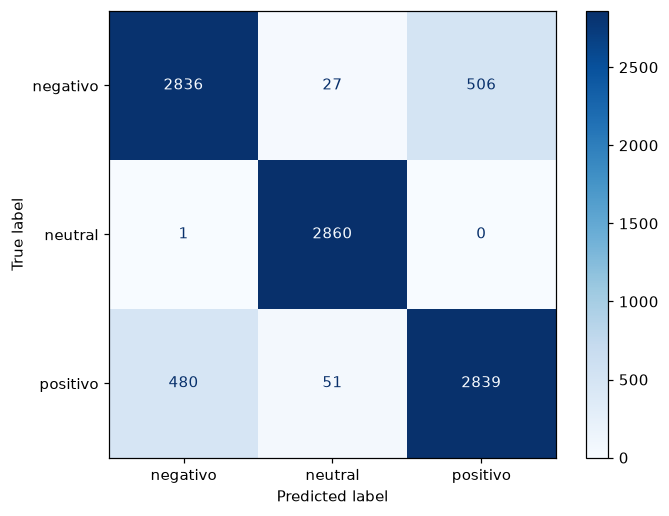

In [17]:
resultados_svm_bloques = cross_validate(
    pipeline_svm_bloques,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    return_estimator=True,
)

display(pd.DataFrame({
    "texto_ultima_oracion": resultados_ultima_oracion["test_score"],
    "svm_bloques": resultados_svm_bloques["test_score"],
}))
print("Accuracy promedio:", resultados_svm_bloques["test_score"].mean())
print("Desviación estándar:", resultados_svm_bloques["test_score"].std())

predicciones_svm_bloques = np.empty(len(X_train), dtype=object)
for (_, indices_validacion), estimador in zip(
    cv.split(X_train, y_train), resultados_svm_bloques["estimator"]
):
    predicciones_svm_bloques[indices_validacion] = estimador.predict(
        X_train.iloc[indices_validacion]
    )

print(classification_report(y_train, predicciones_svm_bloques, digits=3))
ConfusionMatrixDisplay.from_predictions(
    y_train,
    predicciones_svm_bloques,
    labels=["negativo", "neutral", "positivo"],
    cmap="Blues",
)
plt.show()


El cuarto modelo obtuvo 88,91 % de accuracy promedio y una desviación de 0,95 puntos. Mejoró el promedio del tercero en 1,38 puntos y lo superó en cuatro particiones. El recall de positivo y negativo fue aproximadamente 84,2 %, y el de neutral fue 100 %. En Kaggle obtuvo 0.88444; aún no alcanza la meta de 90 %.


## Quinto intento: estructura de las opiniones y árboles

En vez de TF-IDF, usamos 59 características: opiniones positivas y negativas, su posición, los conectores y cómo termina la reseña. HistGradientBoosting combina árboles pequeños que van corrigiendo errores de los anteriores.

El corrector de escritura, las polaridades y los árboles se ajustan solo con entrenamiento en cada partición. Las expresiones están definidas para este tipo de reseñas; esto puede hacer optimista la validación y limitar el uso con otros datos. No usamos etiquetas de eval.


### Normalización y corrección de escritura

Pasamos a minúsculas y quitamos tildes. Corregimos palabras poco frecuentes usando el vocabulario aprendido con entrenamiento.


In [18]:
import collections
from sklearn.ensemble import HistGradientBoostingClassifier

def normalizar(texto):
    texto = unicodedata.normalize('NFKD', str(texto).lower())
    return ''.join(c for c in texto if not unicodedata.combining(c))

LETRAS = 'abcdefghijklmnopqrstuvwxyzñ'

def _ediciones1(w):
    cortes = [(w[:i], w[i:]) for i in range(len(w) + 1)]
    borrados = [a + b[1:] for a, b in cortes if b]
    transpuestos = [a + b[1] + b[0] + b[2:] for a, b in cortes if len(b) > 1]
    sustituidos = [a + c + b[1:] for a, b in cortes if b for c in LETRAS]
    insertados = [a + c + b for a, b in cortes for c in LETRAS]
    return set(borrados + transpuestos + sustituidos + insertados)

class CorrectorTypos:
    """Cambia cada palabra rara (< min_frec apariciones en los textos de entrenamiento, más de 3 letras) por la
    palabra frecuente más común a distancia de edición 1: 'lleego' -> 'llego', 'epsectacular' -> 'espectacular'."""

    def __init__(self, min_frec=5):
        self.min_frec = min_frec

    def fit(self, textos_normalizados):
        self.frecuencia = collections.Counter((w for t in textos_normalizados for w in re.findall('[a-zñ]+', t)))
        self.vocabulario = {w for w, k in self.frecuencia.items() if k >= self.min_frec}
        self.cache = {}
        return self

    def palabra(self, w):
        if w in self.vocabulario or len(w) <= 3:
            return w
        if w not in self.cache:
            candidatas = sorted((v for v in _ediciones1(w) if v in self.vocabulario))
            self.cache[w] = max(candidatas, key=lambda v: self.frecuencia[v]) if candidatas else w
        return self.cache[w]

    def transform(self, texto):
        return re.sub('[a-zñ]+', lambda m: self.palabra(m.group()), texto)


### Expresiones y conectores

Definimos expresiones positivas, negativas y de duda, junto con conectores que relacionan las opiniones.


In [19]:
COPULAS = ['me parecio',
 'me resulto ser',
 'me resulto',
 'resulto ser',
 'resulto',
 'quedo',
 'se ve',
 'se siente',
 'se sintio',
 'se mantuvo',
 'termino siendo',
 'luce',
 'es',
 'esta',
 'fue',
 'me salio',
 'salio',
 'me quedo',
 'anda',
 'se nota',
 'se volvio',
 'funciona',
 'sigue siendo',
 'sigue',
 'me parece',
 'parece',
 'me ha parecido',
 'se ha mantenido',
 'me termino pareciendo',
 'termino pareciendo',
 'vino',
 'me resulta',
 'resulta',
 'queda',
 'se sigue viendo',
 'estuvo']

ADJETIVOS_POS = ['robust[oa]',
 'correct[oa]',
 'nitid[oa]',
 'impecable',
 'liger[oa]',
 'sobresaliente',
 'optim[oa]',
 'redond[oa]',
 'durable',
 'resistente',
 'excelente',
 'espectacular',
 'comodisim[oa]',
 'superior',
 'decente',
 'potente',
 'agradable',
 'estupend[oa]',
 'eficiente',
 'fiable',
 'practic[oa]',
 'solid[oa]',
 'buenisim[oa]',
 'precis[oa]',
 'confiable',
 'cumplidor[a]?',
 'formidable',
 'comod[oa]',
 'rapidisim[oa]',
 'veloz',
 'funcional',
 'complet[oa]',
 'buen[oa]',
 'notable',
 'bien hech[oa]',
 'bien lograd[oa]',
 'bien construid[oa]',
 'bien terminad[oa]',
 'lograd[oa]',
 'de maravilla',
 'genial',
 'perfect[oa]',
 'ideal',
 'brillante',
 'increible',
 'fantastic[oa]',
 'bien',
 'de buena calidad',
 'de calidad',
 'muy buen[oa]']

ADJETIVOS_NEG = ['defectuos[oa]',
 'imprecis[oa]',
 'ordinari[oa]',
 'incomod[oa]',
 'chapucer[oa]',
 'aparatos[oa]',
 'terrible',
 'inconsistente',
 'malisim[oa]',
 'floj[oa]',
 'pobre',
 'olvidable',
 'debil',
 'lentisim[oa]',
 'limitad[oa]',
 'inestable',
 'torpe',
 'deficiente',
 'delicad[oa]',
 'mediocre',
 'basic[oa]',
 'pesim[oa]',
 'fragil',
 'ruidos[oa]',
 'incumplidor[a]?',
 'desagradable',
 'corriente',
 'endeble',
 'decepcionante',
 'mal hech[oa]',
 'mal terminad[oa]',
 'mal construid[oa]',
 'horrible',
 'bastante mal',
 'mal',
 'lent[oa]',
 'malo',
 'mala',
 'de mala calidad',
 'de lo peor']

MODIFICADORES = '(?:(?P<mod>muy|bastante|demasiado|super|algo|un poco|poco|nada|tan|re)\\s+)?'

RE_ADJETIVO = re.compile('\\b(?P<cop>' + '|'.join(sorted(COPULAS, key=len, reverse=True)) + ')\\s+' + MODIFICADORES + '(?P<adj>' + '|'.join(sorted(ADJETIVOS_POS + ADJETIVOS_NEG, key=len, reverse=True)) + ')\\b')

RE_ADJETIVO_POSITIVO = re.compile('^(?:' + '|'.join(ADJETIVOS_POS) + ')$')

FRASES_FIJAS = {'p_cumple_sobra': 'cumple de sobra',
 'p_vida_facil': 'me hizo la vida (?:mas|muy) facil',
 'p_sorprendio_bien': 'me sorprendio para bien',
 'p_cada_peso': 'cada peso que pague por .{0,40}? valio la pena|cada peso que pague '
                'valio la pena|valio cada peso',
 'p_me_encanto': '\\bme encanto\\b|\\bme encantaron\\b',
 'p_feliz': '\\bestoy feliz con|\\btermine feliz con|\\bquede feliz con|me tiene '
            'feliz|me dejo feliz|estoy feliz|sigo estando feliz|feliz con',
 'p_contento': 'me tiene content[oa]|me dejo content[oa]|muy content[oa]|quede '
               'content[oa]|estoy content[oa]',
 'p_satisfecho': 'mas que satisfech[oa]|quede satisfech[oa]|muy satisfech[oa]',
 'p_repetiria': 'repetiria la compra',
 'p_recomiendo_sin': 'l[oa] recomiendo sin (?:pensarlo|dudarlo)|recomiendo .{0,30}?sin '
                     'dudarlo',
 'p_mucho_mejor': 'mucho mejor de lo que',
 'p_me_alegra': 'me alegra haber elegido|me alegra haberl[oa] elegido|me alegra '
                'haberl[oa] comprado',
 'p_tal_como': 'respondio tal como esperaba|tal como esperaba',
 'p_sola_queja': 'ni una sola queja',
 'p_supero': 'supero todas mis expectativas|supero mis expectativas',
 'p_vale_pena': 'vale totalmente la pena|vale la pena',
 'p_cinco_estrellas': 'cinco estrellas',
 'p_ojos_cerrados': 'con los ojos cerrados',
 'p_encantado': 'quede encantad[oa] con|quede encantad[oa]|quedo encantad[oa]|me quedo '
                'encantad[oa]',
 'p_sin_pensarlo': 'volveria a comprar\\w* .{0,40}?sin pensarlo|volveria a comprar\\w* '
                   'sin pensarlo|sin pensarlo dos veces',
 'p_justo_buscando': 'justo lo que (?:estaba buscando|buscaba|necesitaba)',
 'p_acierto': 'todo un acierto',
 'p_encima_media': 'por encima de la media',
 'p_maravilla': 'funciona de maravilla|de maravilla',
 'p_dejo_encantado': 'me dejo encantad[oa]|me tiene encantad[oa]',
 'p_volvi_comprar': 'volvi a comprar',
 'p_con_creces': 'cumple con creces|con creces',
 'p_ni_una_queja': 'ni una queja|una sola queja|no tengo queja|no me quejo',
 'p_me_gusto': 'me gusto (?:bastante|mucho)|me gustaron|me termino gustando|termino '
               'gustandome|si me gusto|me gusto',
 'n_no_vale': 'no vale lo que cuesta',
 'n_dolor_cabeza': 'mas de un dolor de cabeza|dolor de cabeza',
 'n_para_nada': 'no es para nada lo que esperaba|para nada lo que esperaba',
 'n_se_dano': 'se dano antes de lo que esperaba|se dano',
 'n_defraudo': 'defraudo todas mis expectativas|defraudo',
 'n_tire_dinero': 'tire el dinero',
 'n_decepciono': 'me decepciono|me decepcionaron',
 'n_me_arrepiento': 'me arrepiento de haber|me arrepiento es de haber|me arrepenti de '
                    'haber\\w*',
 'n_arrepentido': 'arrepentid[oa] de haber',
 'n_problemas': 'no pare de tener problemas|no para de darme problemas|no paro de darme '
                'problemas|me ha dado problemas',
 'n_no_convencio': 'no me convencio|no me convence|no me termino de convencer',
 'n_mal_rato': 'mas de un mal rato',
 'n_debajo_aceptable': 'por debajo de lo aceptable',
 'n_peor_parece': 'las cosas que peor',
 'n_molesto': 'quede muy molest[oa]|quede molest[oa]',
 'n_no_recomiendo': 'no l[oa] le recomiendo|no le recomiendo|no se l[oa]s? recomiendo|no '
                    'l[oa] recomiendo|no se l[oa]s? recomendaria|recomendaria a nadie',
 'n_dejo_molesto': 'me dejo (?:muy )?molest[oa]',
 'n_complicaciones': 'me trajo complicaciones|me dio problemas|dio problemas|me trajo '
                     'problemas',
 'n_no_funciono': 'no me funciono como esperaba|nunca me funciono como esperaba',
 'n_desilusiono': 'me desilusiono',
 'n_fue_error': 'fue un error',
 'n_una_estrella': 'una sola estrella|una estrella',
 'n_queda_corto': 'se queda muy cort[oa]|se queda cort[oa]',
 'n_ni_regalado': 'ni regalad[oa]|ni aunque me l[oa] regal\\w*|ni me l[oa] regalaron',
 'n_harto': 'termine hart[oa]|quede hart[oa]|termino hart[oa]',
 'n_error_compra': 'un error de compra',
 'n_debajo_media': 'por debajo de la media',
 'n_bastante_mal': 'funciona bastante mal',
 'n_no_gusto': 'no me gusto nada|no me gusto',
 'n_de_lo_peor': 'de lo peor'}

RE_FRASES_FIJAS = [(k, re.compile('\\b(?:' + v + ')')) for k, v in FRASES_FIJAS.items()]

CIERRES_AMBIVALENTES = {'c_juzgue': 'cada quien que juzgue|que cada quien juzgue|cada quien juzgue',
 'c_gustos': 'para gustos,? colores',
 'c_dudas': 'sigo con (?:dudas|la duda)|con la duda|me quede con la duda|sigo '
            'dudando|dudando',
 'c_fufa': 'ni fu ni fa',
 'c_criterio_cada': 'a criterio de cada uno',
 'c_criterio_tu': 'a tu criterio|a su criterio|a criterio',
 'c_no_sabria': 'no sabria (?:bien )?que (?:recomendar|pensar|decir)|no se bien que '
                '(?:pensar|decir|recomendar)|no se que (?:pensar|decir)',
 'c_hay_todo': 'hay de todo',
 'c_sopesalo': 'sopesalo|sopesenlo',
 'c_no_decido': 'no me decido|no me termino de decidir|sin decidirme|no termino de '
                'decidir',
 'c_mejor_peor': 'ni lo mejor ni lo peor',
 'c_bueno_malo': 'ni tan bueno ni tan malo',
 'c_ahi_dejo': 'ahi lo dejo|ahi queda',
 'c_sentimientos': 'sentimientos encontrados',
 'c_conclusiones': 'sacara sus conclusiones|saque sus conclusiones|sus propias '
                   'conclusiones',
 'c_otras_no': 'otras no|lo uno y lo otro|unas cosas? (?:buenas?|mejor)|unos detalles '
               'mejor que otros',
 'c_vueltas': 'dandole vueltas|vuelta al asunto'}

RE_CIERRES = [(k, re.compile('\\b(?:' + v + ')')) for k, v in CIERRES_AMBIVALENTES.items()]

CONECTORES_PLANTILLA = {'fuerte': ['pero al final',
            'pero',
            'aun asi',
            'aun con eso',
            'con todo',
            'al final de cuentas',
            'al final',
            'a fin de cuentas',
            'sin embargo',
            'no obstante',
            'de todos modos',
            'de todas formas',
            'lo que si',
            'ahora bien',
            'aunque',
            'el detalle es que',
            'lo curioso es que',
            'mientras que',
            'eso no quita'],
 'debil': ['eso si', 'igual', 'total', 'en fin', 'en cambio', 'ahora'],
 'aditivo': ['por otro lado',
             'por otra parte',
             'ademas',
             'de paso',
             'por cierto',
             'tambien',
             'aparte',
             'encima',
             'y']}

_LISTA_CONECTORES = sorted([(c, t) for t, cs in CONECTORES_PLANTILLA.items() for c in cs], key=lambda x: -len(x[0]))

RE_CONECTOR_PLANTILLA = re.compile('\\b(' + '|'.join((re.escape(c) for c, _ in _LISTA_CONECTORES)) + ')\\b')

TIPO_CONECTOR_PLANTILLA = {c: t for c, t in _LISTA_CONECTORES}


### Identificación de opiniones

Separamos las oraciones y detectamos opiniones, negaciones y conectores. Conservamos su orden dentro de la reseña.


In [20]:
def oraciones_plantilla(t):
    return [s for s in re.split('(?<=[.!?])\\s+', t.strip()) if s] or ['']

RE_FRAGMENTO = re.compile(',\\s+|;\\s+|\\s+y\\s+(?=(?:el|la|los|las|lo|le|me|no|estoy|quede|siento|termine|recomiendo|volveria|cada|ni)\\b)|\\s+(?=(?:pero|aunque|mientras que|sin embargo)\\b)')

def fragmentos_oracion(s):
    salida, pos, sep = ([], 0, '')
    for m in RE_FRAGMENTO.finditer(s):
        salida.append((pos, m.start(), sep))
        sep = m.group(0).strip() or ' '
        pos = m.end()
    salida.append((pos, len(s), sep))
    return [(a, b, sp) for a, b, sp in salida if s[a:b].strip(' .!?')]

def opiniones_fragmento(f, patron_adjetivo=None):
    hallazgos = []
    for clave, rx in RE_FRASES_FIJAS:
        for m in rx.finditer(f):
            hallazgos.append((clave, m.start(), m.end()))
    for m in (patron_adjetivo or RE_ADJETIVO).finditer(f):
        adj = m.group('adj')
        if adj in ('bien', 'mal') and m.group('cop') in ('es', 'esta', 'fue', 'sigue'):
            continue
        signo = 'a+' if RE_ADJETIVO_POSITIVO.match(adj) else 'a-'
        mod = m.group('mod') or ''
        if mod in ('poco', 'nada'):
            signo = 'a-' if signo == 'a+' else 'a+'
        elif re.search('\\bno\\s+$', f[max(0, m.start() - 4):m.start()]):
            signo = 'a-' if signo == 'a+' else 'a+'
            mod = 'no'
        base = re.sub('[oa]$', '', adj) if ' ' not in adj else adj
        hallazgos.append((f"{signo}:{(mod + ' ' if mod in ('poco', 'nada', 'no') else '')}{base}", m.start(), m.end()))
    hallazgos.sort(key=lambda h: (h[1], -(h[2] - h[1])))
    salida, fin = ([], -1)
    for h in hallazgos:
        if h[1] >= fin:
            salida.append(h)
            fin = h[2]
    return salida

def analizar_resena(t, detector=None):
    """t: texto normalizado y corregido. Devuelve las oraciones, la lista de opiniones (en orden) y el cierre."""
    S = oraciones_plantilla(t)
    opiniones = []
    for si, s in enumerate(S):
        fin_anterior = 0
        for a, b, sep in fragmentos_oracion(s):
            f = s[a:b]
            nucleos = (detector or opiniones_fragmento)(f)
            if not nucleos:
                continue
            for j, (clave, ca, cb) in enumerate(nucleos):
                nb = nucleos[j + 1][1] if j + 1 < len(nucleos) else len(f)
                pa = nucleos[j - 1][2] if j > 0 else 0
                opiniones.append(dict(oracion=si, clave=clave, nucleo=f[ca:cb], inicio_fragmento=f[pa:ca], resto_fragmento=f[cb:nb], separador=sep if j == 0 else 'y', antes=s[fin_anterior:a] if j == 0 else '', ini=a + pa, fin=a + nb, oracion_texto=s))
            fin_anterior = b
    for j, o in enumerate(opiniones):
        sig = opiniones[j + 1] if j + 1 < len(opiniones) and opiniones[j + 1]['oracion'] == o['oracion'] else None
        o['despues'] = o['oracion_texto'][o['fin']:sig['ini'] if sig else len(o['oracion_texto'])]
        conectores = RE_CONECTOR_PLANTILLA.findall(o['antes'] + ' ' + o['inicio_fragmento'] + ' ' + o['separador'])
        o['conector'] = conectores[-1] if conectores else ''
        o['tipo_conector'] = TIPO_CONECTOR_PLANTILLA.get(o['conector'], 'ninguno')
    ultima_oracion = opiniones[-1]['oracion'] if opiniones else -1
    cierre, cierre_oracion = ('', -1)
    for si in range(len(S) - 1, ultima_oracion, -1):
        for clave, rx in RE_CIERRES:
            if rx.search(S[si]):
                cierre, cierre_oracion = (clave, si)
                break
        if cierre:
            break
    cierre_en_linea = ''
    if opiniones and (not cierre):
        for clave, rx in RE_CIERRES:
            if rx.search(opiniones[-1]['despues']):
                cierre_en_linea = clave
                break
    return dict(oraciones=S, opiniones=opiniones, cierre=cierre, cierre_oracion=cierre_oracion, cierre_en_linea=cierre_en_linea)

def polaridad_semantica(clave):
    return 1 if clave.startswith('p_') or clave.startswith('a+') else -1

def es_adjetival(opinion):
    return opinion['clave'][:2] in ('a+', 'a-')

def tipo_de_final(analisis):
    S, ultima = (analisis['oraciones'], analisis['opiniones'][-1])
    relleno = len(S) - 1 - ultima['oracion'] - (1 if analisis['cierre_oracion'] > ultima['oracion'] else 0)
    if analisis['cierre'] or analisis['cierre_en_linea']:
        return ('cierre', relleno)
    return ('relleno' if relleno > 0 else 'opinion', relleno)


### Características y modelo

Convertimos las opiniones en 59 valores numéricos y los usamos como entrada de los árboles. El Pipeline aprende las polaridades y el clasificador dentro de cada partición.


In [21]:
CONECTORES_RASGO = ['eso si',
 'aun asi',
 'al final',
 'con todo',
 'pero',
 'a fin de cuentas',
 'por otro lado',
 'de paso',
 'por cierto',
 'ademas',
 'ahora',
 'y',
 '',
 'lo que si',
 'aunque',
 'sin embargo',
 'pero al final',
 'igual',
 'en cambio',
 'ahora bien',
 'aun con eso']

def rasgos_plantilla(analisis, signo=polaridad_semantica):
    """59 rasgos de una reseña, casi todos «firmados»: valen +1 o -1 según la polaridad de la opinión implicada."""
    ops, S, f = (analisis['opiniones'], analisis['oraciones'], {})
    n = len(ops)
    signos = [signo(o['clave']) for o in ops]
    f['sin_opinion'] = float(n == 0)
    f['n_opiniones'] = n
    f['n_positivas'] = sum((s == 1 for s in signos))
    f['n_negativas'] = sum((s == -1 for s in signos))
    f['n_adjetivales'] = sum((es_adjetival(o) for o in ops))
    f['n_fijas'] = n - f['n_adjetivales']
    f['signo_mayoria'] = float(np.sign(f['n_positivas'] - f['n_negativas']))
    s_primera = signos[0] if n else 0
    s_ultima = signos[-1] if n else 0
    f['signo_primera'] = s_primera
    f['signo_ultima'] = s_ultima
    coherente = n > 0 and len(set(signos)) == 1
    mixta = len(set(signos)) == 2
    f['coherente'] = float(coherente)
    f['signo_coherente'] = s_ultima if coherente else 0
    f['mixta'] = float(mixta)
    adj = [s for s, o in zip(signos, ops) if es_adjetival(o)]
    fij = [s for s, o in zip(signos, ops) if not es_adjetival(o)]
    f['signo_ultima_adj'] = adj[-1] if adj else 0
    f['signo_primera_adj'] = adj[0] if adj else 0
    f['signo_ultima_fija'] = fij[-1] if fij else 0
    f['signo_mixta_A'] = s_ultima if mixta and adj else 0
    f['signo_mixta_B'] = s_ultima if mixta and (not adj) else 0
    jc = [j for j in range(1, n) if signos[j] != signos[j - 1]][-1] if mixta else n - 1
    con = ops[jc]['conector'] if n else ''
    tipo = ops[jc]['tipo_conector'] if n else 'ninguno'
    for t in ['fuerte', 'debil', 'aditivo', 'ninguno']:
        f['conector_' + t] = float(tipo == t)
        f['signo_mixta_conector_' + t] = s_ultima if tipo == t and mixta else 0
    for c in CONECTORES_RASGO:
        f['signo_mixta_con=' + (c or 'nada')] = s_ultima if con == c and mixta else 0
    if n:
        ultima = ops[-1]
        final, relleno = tipo_de_final(analisis)
        f['relleno_despues'] = relleno
        f['cierre'] = float(bool(analisis['cierre']))
        f['cierre_en_linea'] = float(bool(analisis['cierre_en_linea']))
        f['termina_opinion'] = float(final == 'opinion')
        f['termina_relleno'] = float(final == 'relleno')
        f['termina_cierre'] = float(final == 'cierre')
        f['signo_ultima_x_termina_opinion'] = s_ultima * f['termina_opinion']
        f['signo_ultima_x_termina_relleno'] = s_ultima * f['termina_relleno']
        f['signo_ultima_x_termina_cierre'] = s_ultima * f['termina_cierre']
        f['posicion_ultima'] = ultima['oracion'] / max(1, len(S) - 1)
        cola = ultima['resto_fragmento'] + ' ' + ultima['despues']
        f['signo_ultima_eso_si_cola'] = s_ultima * float(bool(re.search('\\beso si\\b', cola)))
        f['signo_ultima_algun_fuerte'] = s_ultima * float(any((o['tipo_conector'] == 'fuerte' for o in ops[1:])))
    else:
        for k in ['relleno_despues', 'cierre', 'cierre_en_linea', 'termina_opinion', 'termina_relleno', 'termina_cierre', 'signo_ultima_x_termina_opinion', 'signo_ultima_x_termina_relleno', 'signo_ultima_x_termina_cierre', 'posicion_ultima', 'signo_ultima_eso_si_cola', 'signo_ultima_algun_fuerte']:
            f[k] = 0.0
    f['n_oraciones'] = len(S)
    return f

def _es_positivo(v):
    return v == 'positivo' or (not isinstance(v, str) and int(v) == 2)

def _es_negativo(v):
    return v == 'negativo' or (not isinstance(v, str) and int(v) == 0)

class RasgosPlantilla(TransformerMixin, BaseEstimator):
    """Texto crudo -> DataFrame de rasgos estructurales. En fit() se ajustan, solo con los textos de entrenamiento,
    el corrector de typos y (modo_polaridad='aprendida') la polaridad de cada clave de opinión: la etiqueta
    mayoritaria de las reseñas de entrenamiento que tienen esa única opinión (con < min_n apariciones se usa la
    polaridad semántica del inventario)."""

    def __init__(self, min_frec=5, modo_polaridad='aprendida', min_n=3):
        self.min_frec = min_frec
        self.modo_polaridad = modo_polaridad
        self.min_n = min_n

    def _ajustar(self, X, y):
        if self.modo_polaridad not in ('aprendida', 'semantica'):
            raise ValueError('modo_polaridad debe ser aprendida o semantica')
        if self.modo_polaridad == 'aprendida' and (y is None or len(X) != len(y)):
            raise ValueError('La polaridad aprendida requiere una etiqueta por texto')
        self.corrector_ = CorrectorTypos(self.min_frec).fit([normalizar(t) for t in X])
        self.lexico_ = {}
        analisis = self.analizar(X)
        if self.modo_polaridad == 'aprendida':
            conteo = {}
            for a, v in zip(analisis, y):
                if len(a['opiniones']) != 1 or not (_es_positivo(v) or _es_negativo(v)):
                    continue
                conteo.setdefault(a['opiniones'][0]['clave'], [0, 0])[int(_es_positivo(v))] += 1
            self.lexico_ = {k: 1 if pos > neg else -1 for k, (neg, pos) in conteo.items() if neg + pos >= self.min_n}
        return analisis

    def fit(self, X, y=None):
        self._ajustar(X, y)
        return self

    def fit_transform(self, X, y=None):
        return self._tabla(self._ajustar(X, y))

    def signo(self, clave):
        return self.lexico_.get(clave, polaridad_semantica(clave))

    def analizar(self, X):
        return [analizar_resena(self.corrector_.transform(normalizar(t))) for t in X]

    def _tabla(self, analisis):
        return pd.DataFrame([rasgos_plantilla(a, self.signo) for a in analisis]).astype(float)

    def transform(self, X):
        return self._tabla(self.analizar(X))

def modelo_estructural(random_state=42):
    return Pipeline([('rasgos', RasgosPlantilla(modo_polaridad='aprendida')), ('clf', HistGradientBoostingClassifier(learning_rate=0.05, max_iter=200, max_leaf_nodes=15, min_samples_leaf=20, early_stopping=False, random_state=random_state))])


### Evaluación del quinto intento

Usamos las mismas cinco particiones para compararlo con la SVM.


In [22]:
from threadpoolctl import threadpool_limits

pipeline_estructural = modelo_estructural(random_state=RANDOM_STATE)

with threadpool_limits(limits=2):
    resultados_estructural = cross_validate(
        pipeline_estructural,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_estimator=True,
    )

display(pd.DataFrame({
    "svm_bloques": resultados_svm_bloques["test_score"],
    "estructural": resultados_estructural["test_score"],
}))
print("Accuracy promedio:", resultados_estructural["test_score"].mean())
print("Desviación estándar:", resultados_estructural["test_score"].std())


Accuracy promedio: 0.9090624999999999
Desviación estándar: 0.008504747448729259


,svm_bloques,estructural
0,0.894792,0.914062
1,0.876563,0.893229
2,0.901042,0.918229
3,0.893750,0.909375
4,0.879167,0.910417


### Resultados por clase

Reutilizamos los modelos de las cinco particiones para revisar sus errores. Cada reseña se predice con un modelo que no la usó para ajustar sus componentes.


              precision    recall  f1-score   support

    negativo      0.869     0.882     0.875      3369
     neutral      0.993     0.995     0.994      2861
    positivo      0.878     0.864     0.871      3370

    accuracy                          0.909      9600
   macro avg      0.913     0.913     0.913      9600
weighted avg      0.909     0.909     0.909      9600



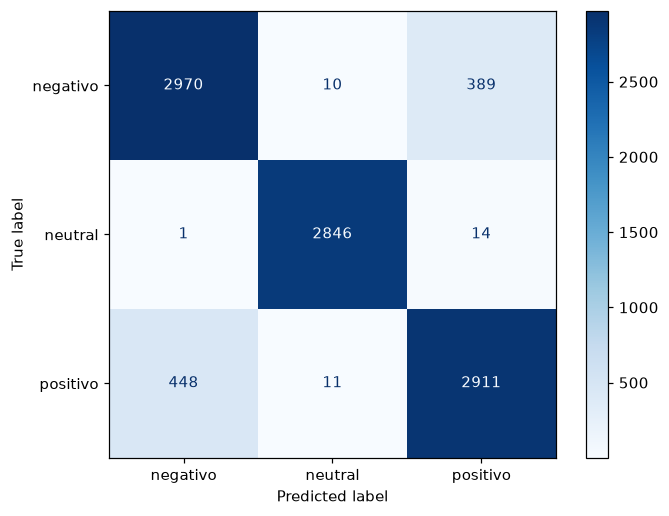

In [23]:
predicciones_estructural = np.empty(len(X_train), dtype=object)
with threadpool_limits(limits=2):
    for (_, indices_validacion), estimador in zip(
        cv.split(X_train, y_train), resultados_estructural["estimator"]
    ):
        predicciones_estructural[indices_validacion] = estimador.predict(
            X_train.iloc[indices_validacion]
        )

print(classification_report(y_train, predicciones_estructural, digits=3))
ConfusionMatrixDisplay.from_predictions(
    y_train,
    predicciones_estructural,
    labels=["negativo", "neutral", "positivo"],
    cmap="Blues",
)
plt.show()


### Comprobación con otras particiones

Repetimos la evaluación con otra semilla, sin cambiar el modelo ni sus parámetros. Las 2.400 reseñas finales siguen sin usarse para ajustar o comparar estos intentos.


In [24]:
cv_verificacion = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=2024,
)
with threadpool_limits(limits=2):
    verificacion_estructural = cross_validate(
        pipeline_estructural,
        X_train,
        y_train,
        cv=cv_verificacion,
        scoring="accuracy",
    )

display(pd.DataFrame({"accuracy": verificacion_estructural["test_score"]}))
print("Accuracy de comprobación:", verificacion_estructural["test_score"].mean())


Accuracy de comprobación: 0.9090625000000001


,accuracy
0,0.909375
1,0.916667
2,0.917708
3,0.898438
4,0.903125


El quinto modelo obtuvo **90,91 %** de accuracy promedio y una desviación de 0,85 puntos. Con otras particiones repitió el mismo promedio, pero en Kaggle bajó a **0.87333**, frente al 0.88444 del cuarto.

Su resultado local no se trasladó al envío. Las reglas pueden perder opiniones escritas de formas diferentes a las de entrenamiento. En el siguiente intento comprobaremos esa debilidad y ampliaremos el detector.


## Sexto intento: detector más flexible

El detector anterior no reconoce opiniones como "se mantuvo sorprendentemente buena" o "terminó resultando excelente". Si pierde la opinión, los árboles reciben una descripción incompleta de la reseña.

Permitimos adverbios terminados en -mente y variantes de los verbos usados para expresar opiniones. Conservamos las negaciones, las 59 características y los mismos parámetros de los árboles. Todo lo aprendido de los datos sigue ajustándose dentro de cada partición.


In [25]:
ADJETIVOS_ALT = '|'.join(sorted(ADJETIVOS_POS + ADJETIVOS_NEG, key=len, reverse=True))

COPULAS_ALT = '|'.join(sorted(COPULAS, key=len, reverse=True))

RX_MENTE = '(?:[a-z]+mente\\s+){0,2}'

RX_RAICES = '(?:(?:me|se|le|te|nos)\\s+)?(?:(?:termin|acab)(?:o|a|e|an|aron|aba|ando)\\s+)?(?:result|parec|pareci|sint|sient|mant|qued|sal|luc|volv|not)\\w*'

def regex_adjetivo_robusta(mente=True, raices=True):
    copulas = COPULAS_ALT + ('|' + RX_RAICES if raices else '')
    adverbios = RX_MENTE if mente else ''
    return re.compile('\\b(?P<cop>' + copulas + ')\\s+' + adverbios + MODIFICADORES + adverbios + '(?P<adj>' + ADJETIVOS_ALT + ')\\b')

RE_ADJETIVO_ROBUSTO = regex_adjetivo_robusta()

class RasgosGramaticales(RasgosPlantilla):
    def analizar(self, X):
        return [
            analizar_resena(
                self.corrector_.transform(normalizar(texto)),
                lambda fragmento: opiniones_fragmento(fragmento, RE_ADJETIVO_ROBUSTO),
            )
            for texto in X
        ]

def modelo_gramatical(random_state=42):
    return Pipeline([
        ("rasgos", RasgosGramaticales()),
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=200,
            max_leaf_nodes=15,
            min_samples_leaf=20,
            early_stopping=False,
            random_state=random_state,
        )),
    ])



### Comprobación del detector

Usamos frases de ejemplo para revisar que las variantes se reconozcan y que las negaciones mantengan su efecto.


In [26]:
ejemplos_detector = [
    "La cámara es excelente.",
    "La cámara terminó resultando excelente.",
    "La batería se mantuvo sorprendentemente buena.",
    "La batería no es cómoda.",
    "La batería no terminó resultando cómoda.",
]
comparacion_detector = []
for texto in ejemplos_detector:
    texto_normalizado = normalizar(texto)
    original = opiniones_fragmento(texto_normalizado)
    corregido = opiniones_fragmento(texto_normalizado, RE_ADJETIVO_ROBUSTO)
    comparacion_detector.append({
        "texto": texto,
        "original": [opinion[0] for opinion in original],
        "corregido": [opinion[0] for opinion in corregido],
    })

assert comparacion_detector[1]["original"] == []
assert comparacion_detector[1]["corregido"]
assert comparacion_detector[-1]["corregido"][0].startswith("a-")
display(pd.DataFrame(comparacion_detector))


,texto,original,corregido
0,La cámara es excelente.,[a+:excelente],[a+:excelente]
1,La cámara terminó resultando excelente.,[],[a+:excelente]
2,La batería se mantuvo sorprendentemente buena.,[],[a+:buen]
3,La batería no es cómoda.,[a-:no comod],[a-:no comod]
4,La batería no terminó resultando cómoda.,[],[a-:no comod]


### Validación y prueba con variantes

Usamos las mismas cinco particiones. También añadimos "honestamente" entre el verbo y el adjetivo en las reseñas evaluadas, sin cambiar su sentimiento. No agregamos esos textos al entrenamiento: comprobamos si el modelo resiste la variación.


In [27]:
pipeline_gramatical = modelo_gramatical(random_state=RANDOM_STATE)

with threadpool_limits(limits=2):
    resultados_gramatical = cross_validate(
        pipeline_gramatical,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_estimator=True,
    )

display(pd.DataFrame({
    "quinto_modelo": resultados_estructural["test_score"],
    "sexto_modelo": resultados_gramatical["test_score"],
}))
print("Accuracy promedio:", resultados_gramatical["test_score"].mean())
print("Desviación estándar:", resultados_gramatical["test_score"].std())

def insertar_adverbio(texto):
    return RE_ADJETIVO.sub(
        lambda m: m["cop"] + " honestamente "
        + ((m["mod"] + " ") if m["mod"] else "") + m["adj"],
        normalizar(texto),
    )

predicciones_gramatical = np.empty(len(X_train), dtype=object)
robustez_original, robustez_gramatical = [], []
with threadpool_limits(limits=2):
    for (_, indices), original, corregido in zip(
        cv.split(X_train, y_train),
        resultados_estructural["estimator"],
        resultados_gramatical["estimator"],
    ):
        textos = X_train.iloc[indices]
        etiquetas = y_train.iloc[indices]
        predicciones_gramatical[indices] = corregido.predict(textos)
        variantes = textos.map(insertar_adverbio)
        robustez_original.append(accuracy_score(etiquetas, original.predict(variantes)))
        robustez_gramatical.append(accuracy_score(etiquetas, corregido.predict(variantes)))

display(pd.DataFrame({
    "validación normal": [
        resultados_estructural["test_score"].mean(),
        resultados_gramatical["test_score"].mean(),
    ],
    "con adverbios": [np.mean(robustez_original), np.mean(robustez_gramatical)],
}, index=["quinto modelo", "sexto modelo"]))
print(classification_report(y_train, predicciones_gramatical, digits=3))


Accuracy promedio: 0.9079166666666667
Desviación estándar: 0.007956315189136788
              precision    recall  f1-score   support

    negativo      0.864     0.884     0.874      3369
     neutral      0.993     0.994     0.994      2861
    positivo      0.880     0.858     0.869      3370

    accuracy                          0.908      9600
   macro avg      0.912     0.912     0.912      9600
weighted avg      0.908     0.908     0.908      9600



,quinto_modelo,sexto_modelo
0,0.914062,0.913021
1,0.893229,0.892708
2,0.918229,0.914062
3,0.909375,0.912500
4,0.910417,0.907292


,validación normal,con adverbios
quinto modelo,0.909062,0.48375
sexto modelo,0.907917,0.90750


El sexto obtuvo **90,79 %** en validación normal y **90,75 %** con adverbios añadidos. El quinto obtuvo 90,91 % y cayó a 48,38 % en esa misma prueba. El promedio normal no mejoró; la corrección evita una falla concreta del detector.

También probamos un respaldo más general para detectar adjetivos (90,77 %) y combinarlo con SVM calibrada (90,78 %). No aportaron una mejora clara; conservamos la corrección gramatical más sencilla. La prueba cubre estas variantes, no todas las formas posibles de escribir una reseña.

En Kaggle, el sexto obtuvo **0.88666**, frente al 0.87333 del quinto y al 0.88444 del cuarto. Mejoró el score público, aunque todavía quedó por debajo de 90 %. Las 2.400 reseñas finales siguen reservadas.


## Séptimo intento: combinación de modelos

Combinamos el detector gramatical, una SVM calibrada y un modelo de stacking. El stacking evalúa seis partes de la reseña con regresión logística y aprende a combinar sus probabilidades con árboles.

Usamos texto completo, fragmentos desde conectores, última y penúltima oración. El voto final promedia probabilidades con pesos fijos de 50 % para el detector, 30 % para el stacking y 20 % para la SVM. Elegimos esos pesos antes de evaluar esta combinación, sin usar etiquetas de eval.

Stacking y calibración usan particiones internas del entrenamiento. TF-IDF se ajusta dentro de cada modelo, para que sus vocabularios no usen las reseñas evaluadas. Esta configuración tarda más en entrenar que las anteriores.


In [28]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.base import clone

CONECTORES_FUERTES = [
    "pero al final", "pero", "aun asi", "aun con eso", "con todo",
    "al final de cuentas", "al final", "a fin de cuentas", "sin embargo",
    "no obstante", "de todos modos", "de todas formas", "lo que si",
    "ahora bien", "aunque",
]
CONECTORES_DEBILES = ["eso si", "igual", "total", "en fin", "en cambio"]

def patron_bloques(conectores):
    return re.compile(
        r"(?:^|(?<=[.!?,;])\s*)(?:"
        + "|".join(re.escape(c) for c in sorted(conectores, key=len, reverse=True))
        + r")\b"
    )

class BloquesAmpliados(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        textos = [normalizar(texto) for texto in X]
        oraciones = [oraciones_plantilla(texto) for texto in textos]
        def posterior(texto, patron):
            coincidencias = list(patron.finditer(texto))
            return texto[coincidencias[-1].start():] if coincidencias else ""
        fuerte = patron_bloques(CONECTORES_FUERTES)
        debil = patron_bloques(CONECTORES_DEBILES)
        ambos = patron_bloques(CONECTORES_FUERTES + CONECTORES_DEBILES)
        return pd.DataFrame({
            "completo": textos,
            "post": [posterior(t, ambos) for t in textos],
            "post_fuerte": [posterior(t, fuerte) for t in textos],
            "post_debil": [posterior(t, debil) for t in textos],
            "ultima": [o[-1] for o in oraciones],
            "penultima": [o[-2] if len(o) > 1 else "" for o in oraciones],
        })

def modelo_stacking_bloques():
    modelos = []
    for bloque in ["completo", "post", "post_fuerte", "post_debil", "ultima", "penultima"]:
        vectorizador = ColumnTransformer([
            ("palabras", TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=2), bloque),
            ("caracteres", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5),
                                         sublinear_tf=True, min_df=3), bloque),
        ])
        modelos.append((bloque, Pipeline([
            ("tfidf", vectorizador),
            ("lr", LogisticRegression(C=5, max_iter=5000, random_state=42)),
        ])))
    meta = HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=300, max_leaf_nodes=15,
        min_samples_leaf=40, early_stopping=False, random_state=42,
    )
    return Pipeline([
        ("bloques", BloquesAmpliados()),
        ("stack", StackingClassifier(
            modelos, final_estimator=meta, stack_method="predict_proba",
            cv=StratifiedKFold(3, shuffle=True, random_state=1),
        )),
    ])

def modelo_ensemble():
    svm = CalibratedClassifierCV(
        clone(pipeline_svm_bloques), method="sigmoid", ensemble=False,
        cv=StratifiedKFold(3, shuffle=True, random_state=42),
    )
    return VotingClassifier([
        ("gramatical", modelo_gramatical()),
        ("stacking", modelo_stacking_bloques()),
        ("svm", svm),
    ], voting="soft", weights=[0.5, 0.3, 0.2])


### Evaluación del conjunto

Comparamos con el sexto intento usando las mismas cinco particiones. Reutilizamos los modelos entrenados para obtener el reporte por clase.


In [29]:
pipeline_ensemble = modelo_ensemble()
with threadpool_limits(limits=2):
    resultados_ensemble = cross_validate(
        pipeline_ensemble,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_estimator=True,
    )

display(pd.DataFrame({
    "detector_gramatical": resultados_gramatical["test_score"],
    "combinacion": resultados_ensemble["test_score"],
}))
print("Accuracy promedio:", resultados_ensemble["test_score"].mean())
print("Desviación estándar:", resultados_ensemble["test_score"].std())

predicciones_ensemble = np.empty(len(X_train), dtype=object)
with threadpool_limits(limits=2):
    for (_, indices), estimador in zip(
        cv.split(X_train, y_train), resultados_ensemble["estimator"]
    ):
        predicciones_ensemble[indices] = estimador.predict(X_train.iloc[indices])
print(classification_report(y_train, predicciones_ensemble, digits=3))


Accuracy promedio: 0.9112500000000001
Desviación estándar: 0.009024705673871028
              precision    recall  f1-score   support

    negativo      0.879     0.872     0.875      3369
     neutral      0.993     0.998     0.995      2861
    positivo      0.874     0.877     0.875      3370

    accuracy                          0.911      9600
   macro avg      0.915     0.916     0.915      9600
weighted avg      0.911     0.911     0.911      9600



,detector_gramatical,combinacion
0,0.913021,0.922917
1,0.892708,0.899479
2,0.914062,0.918750
3,0.912500,0.912500
4,0.907292,0.902604


La combinación obtuvo **91,13 %** de accuracy promedio, con una desviación de 0,90 puntos. Superó el 90,79 % del detector gramatical solo.

En Kaggle obtuvo **0.90000 (90 %)**, nuestro mejor score público confirmado. Alcanzamos el 90 % exacto, no un valor superior. Este resultado no garantiza el score privado. Conservamos los envíos anteriores para comparar.


## Octavo intento: stacking con contexto de las opiniones

El séptimo promedia tres modelos con pesos fijos. Ahora dejamos que un meta-modelo aprenda cómo combinar seis regresiones logísticas por bloques y un clasificador de estructura.

Ampliamos de 59 a 165 rasgos: distinguimos las últimas tres opiniones, sus conectores, negaciones, distancia al final y tipo de cierre. El meta-modelo recibe 21 probabilidades, tres por cada uno de los siete clasificadores.

Cada probabilidad usada para entrenar el meta-modelo se obtiene sin entrenar ese clasificador con la reseña correspondiente. El corrector, el léxico y los TF-IDF se ajustan dentro de esas particiones. Reducimos las hojas del meta-modelo a 7 y añadimos regularización L2 para limitar su complejidad. Este intento cambia representación y combinación; no atribuimos el resultado a un solo cambio.


In [30]:
class RasgosContextuales(RasgosGramaticales):
    def _tabla(self, analisis):
        filas = []
        for a in analisis:
            f = rasgos_plantilla(a, self.signo)
            opiniones = a["opiniones"]
            total = len(a["oraciones"])
            for puesto in range(3):
                o = opiniones[-1 - puesto] if len(opiniones) > puesto else None
                prefijo = f"opinion_{puesto + 1}_"
                f[prefijo + "signo"] = self.signo(o["clave"]) if o else 0
                f[prefijo + "adjetivo"] = float(es_adjetival(o)) if o else 0
                f[prefijo + "distancia_final"] = total - 1 - o["oracion"] if o else -1
                f[prefijo + "negada"] = float(o is not None and bool(re.search(r"\b(?:no|poco|nada)\b", o["nucleo"])))
                for tipo in ["fuerte", "debil", "aditivo", "ninguno"]:
                    f[prefijo + tipo] = float(o is not None and o["tipo_conector"] == tipo)
                for conector in CONECTORES_RASGO:
                    f[prefijo + "con=" + (conector or "nada")] = float(o is not None and o["conector"] == conector)
            if len(opiniones) >= 2:
                f["opiniones_misma_oracion"] = float(opiniones[-1]["oracion"] == opiniones[-2]["oracion"])
                f["separacion_ultimas"] = opiniones[-1]["oracion"] - opiniones[-2]["oracion"]
            else:
                f["opiniones_misma_oracion"] = 0.0
                f["separacion_ultimas"] = -1.0
            for clave in CIERRES_AMBIVALENTES:
                f["cierre=" + clave] = float(a["cierre"] == clave or a["cierre_en_linea"] == clave)
            filas.append(f)
        return pd.DataFrame(filas).astype(float)


def modelo_contextual():
    return Pipeline([
        ("rasgos", RasgosContextuales()),
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=200, max_leaf_nodes=15,
            min_samples_leaf=20, early_stopping=False, random_state=RANDOM_STATE,
        )),
    ])

def modelo_stacking_contextual():
    base = modelo_stacking_bloques()
    modelos = []
    for nombre, clasificador in base.named_steps["stack"].estimators:
        modelos.append((nombre, Pipeline([
            ("bloques", BloquesAmpliados()),
            ("modelo", clasificador),
        ])))
    modelos.append(("contexto", modelo_contextual()))
    return StackingClassifier(
        modelos,
        final_estimator=HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=300, max_leaf_nodes=7,
            min_samples_leaf=40, l2_regularization=1.0,
            early_stopping=False, random_state=RANDOM_STATE,
        ),
        stack_method="predict_proba",
        cv=StratifiedKFold(3, shuffle=True, random_state=1),
    )


### Pruebas exploratorias

Antes de elegir el octavo, comparamos estos cambios sobre las mismas cinco particiones. No usamos la reserva final ni etiquetas de eval. Las configuraciones descartadas también ayudan a explicar la elección.

| Prueba | Accuracy CV | Decisión |
|---|---|---|
| Contexto + HGB (15 hojas, mínimo 20, 200 iteraciones) | 90,72 % | Más rasgos por sí solos no mejoraron. |
| Contexto + Random Forest (300 árboles, mínimo 10, max_features=0.8) | 91,02 % | No superó al séptimo. |
| SVM sobre texto, dos opiniones y cierre; C=0.3 / 1 / 3 | 90,47 / 90,17 / 89,90 % | Aumentar C no ayudó. |
| Sexto + stacking original + SVM de opiniones (50/30/20) | 91,24 % | Mejora menor que el stacking contextual. |
| Sexto + stacking contextual + SVM de opiniones (50/30/20) | 91,22 % | El voto fijo no mejoró el stacking solo. |

Estos resultados sirvieron para seleccionar la configuración. Reutilizar validación para elegir entre intentos puede hacer optimista el mejor promedio; por eso conservamos una evaluación final aparte.


Accuracy promedio: 0.9133333333333333
Desviación estándar: 0.005378471101427315
              precision    recall  f1-score   support

    negativo      0.888     0.865     0.876      3369
     neutral      0.999     0.999     0.999      2861
    positivo      0.867     0.890     0.878      3370

    accuracy                          0.913      9600
   macro avg      0.918     0.918     0.918      9600
weighted avg      0.914     0.913     0.913      9600



,séptimo,octavo,F1 macro octavo
0,0.922917,0.915625,0.919653
1,0.899479,0.905729,0.910482
2,0.918750,0.920833,0.924724
3,0.912500,0.915625,0.919852
4,0.902604,0.908854,0.913347


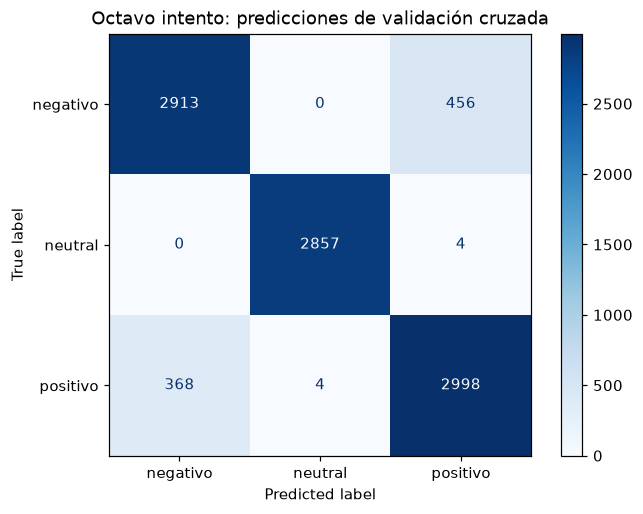

In [31]:
pipeline_contextual = modelo_stacking_contextual()
with threadpool_limits(limits=2):
    resultados_contextual = cross_validate(
        pipeline_contextual, X_train, y_train, cv=cv,
        scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
        return_estimator=True,
    )

display(pd.DataFrame({
    "séptimo": resultados_ensemble["test_score"],
    "octavo": resultados_contextual["test_accuracy"],
    "F1 macro octavo": resultados_contextual["test_f1_macro"],
}))
print("Accuracy promedio:", resultados_contextual["test_accuracy"].mean())
print("Desviación estándar:", resultados_contextual["test_accuracy"].std())

predicciones_contextual = np.empty(len(X_train), dtype=object)
with threadpool_limits(limits=2):
    for (_, indices), estimador in zip(
        cv.split(X_train, y_train), resultados_contextual["estimator"]
    ):
        predicciones_contextual[indices] = estimador.predict(X_train.iloc[indices])

print(classification_report(y_train, predicciones_contextual, digits=3))
ConfusionMatrixDisplay.from_predictions(
    y_train, predicciones_contextual,
    labels=["negativo", "neutral", "positivo"], cmap="Blues",
)
plt.title("Octavo intento: predicciones de validación cruzada")
plt.show()


El octavo obtuvo **91,33 %** local y una desviación de **0,54 puntos**. Clasificó correctamente 20 reseñas más de las 9.600 que el séptimo, una mejora de 0,21 puntos porcentuales. Es una mejora pequeña, no una garantía de alcanzar 0,91 público.

El F1 de neutral fue cercano a 1, mientras que negativo y positivo quedaron cerca de 0,88. El recall de positivo subió de 87,72 % a 88,96 %, pero el de negativo bajó de 87,21 % a 86,46 %: no mejoramos todas las clases. La dificultad sigue siendo distinguir reseñas con elogios y críticas. El score público del octavo está pendiente.


## Análisis de errores

Revisamos solo predicciones de validación cruzada del conjunto de desarrollo. Mostramos las confusiones y ejemplos mezclados para entender las limitaciones, no para cambiar etiquetas ni memorizar reseñas.


In [32]:
revision_errores = pd.DataFrame({
    "text": X_train.to_numpy(),
    "label": y_train.to_numpy(),
    "prediccion": predicciones_contextual,
})
revision_errores["error"] = revision_errores["label"] != revision_errores["prediccion"]
errores = revision_errores.loc[revision_errores["error"]].copy()

display(errores.groupby(["label", "prediccion"]).size().rename("Cantidad").to_frame())
with pd.option_context("display.max_colwidth", 220):
    display(errores.sample(min(6, len(errores)), random_state=RANDOM_STATE)[
        ["text", "label", "prediccion"]
    ])

detector_revision = RasgosContextuales().fit(X_train, y_train)
analisis_revision = detector_revision.analizar(X_train)
revision_errores["opiniones_mixtas"] = [
    len({detector_revision.signo(o["clave"]) for o in a["opiniones"]}) > 1
    for a in analisis_revision
]
display(revision_errores.groupby("opiniones_mixtas").agg(
    cantidad=("error", "size"), tasa_error=("error", "mean"),
))


Cantidad
label    prediccion          
negativo positivo         456
neutral  positivo           4
positivo negativo         368
         neutral            4

,text,label,prediccion
6927,"Pedí esto a mediados de mes y llegó en unos cuatro días a mi casa, en la caja venía todo tal cual la descripción. Antes de comprarlo tuve una duda y escribí por el chat, me atendieron bien y me resolvieron rápido, volvería a comprar la atención al cliente sin pensarlo. Ya llevo un par de semanas usándolo casi a diario en las tardes. Ahora, ya cuando me puse a configurarlo, quedé muy molesto con el menú de ajustes.",positivo,negativo
9487,"No tengo ni una sola queja del sonido. Por cierto, siento que tiré el dinero con el teclado. Sigo con dudas, la verdad.",negativo,positivo
3323,"Lo compre a mediados de mes y llego en tres dias a mi casa en Guadalajara. La resistencia al auga funciona bastante mal, la probe apeas bajo el lavabo y ya se noto. El tamano me encanto de principio a fin, lo uso diario en la mochila para el trabajo.",negativo,positivo
6282,Compre este aparato a mediados de marzo y me llego en unos cuatro dias en una caja bastante sencilla. La resistencia al agua esta por encima de la media. Lo uso en el bano de la casa casi todos los dias desde que llego. El motor defraudo todas mis expectativas.,negativo,positivo
1875,"Hace un mes lo compré para el trabajo, tardó como cuatro días en llegar a la oficina. Me decepcionó la conexión de principio a fin, la verdad. Eso sí, la aplicación superó todas mis expectativas. Ni tan bueno ni tan malo, la verdad no sé qué pensar.",positivo,negativo
7854,"Me llegó el paquete el jueves a la casa de mi hermana, donde andaba de visita, y estoy feliz con el empaque, venía todo bien acomodado. El teclado lo conecté por USB a la compu, sin pilas ni nada. De paso, el teclado funciona bastante mal. Uso para escribir mails y navegar, nada del otro mundo. Ni lo mejor ni lo peor.",negativo,positivo


,cantidad,tasa_error
opiniones_mixtas,,
False,4566,0.005475
True,5034,0.160310


De los 832 errores del octavo, 824 fueron confusiones entre positivo y negativo. La tasa de error fue 16,03 % en las reseñas detectadas como mixtas y 0,55 % en las demás. La última opinión no siempre determina la etiqueta: conectores y cierres cambian la interpretación. El detector también puede omitir expresiones que no estén en su inventario.

La agrupación por opiniones mixtas es descriptiva: ese detector se ajusta con desarrollo completo, pero no cambia las predicciones ya obtenidas por CV. Como mejora futura probaríamos otras formas de representar negaciones y cierres, con nueva validación; no reajustaremos usando la reserva final.


## Registro de experimentos

El score público se anota después de cada envío y no reemplaza la evaluación local.

| Experimento | Configuración | Accuracy CV | Desviación | Score público Kaggle | Conclusión |
|---|---|---|---|---|---|
| 1 | TF-IDF de palabras individuales + regresión logística | 72,39 % | 1,59 puntos | 0.72333 | Dificultad con positivo y negativo. |
| 2 | TF-IDF con bigramas + regresión logística | 72,32 % | 1,63 puntos | 0.72777 | No mejora el promedio local. |
| 3 | Texto completo y última oración + regresión logística | 87,53 % | 1,55 puntos | 0.88000 | La posición de las palabras ayuda. |
| 4 | SVM + palabras y caracteres por bloques | 88,91 % | 0,95 puntos | 0.88444 | Mejora, pero sigue debajo de 90 %. |
| 5 | Rasgos estructurales + HistGradientBoosting | 90,91 % | 0,85 puntos | 0.87333 | Mejor CV, pero peor score público que el cuarto. |
| 6 | Detector gramatical flexible + HistGradientBoosting | 90,79 % | 0,80 puntos | 0.88666 | Resiste mejor los adverbios y mejora el score público del quinto. |
| 7 | Detector gramatical + stacking por bloques + SVM calibrada | 91,13 % | 0,90 puntos | 0.90000 | Mejor score público confirmado; alcanza el 90 % público. |
| 8 | Stacking contextual: seis regresiones logísticas y rasgos estructurales | 91,33 % | 0,54 puntos | Pendiente | Mejor promedio local, con una mejora pequeña. |

La línea base oficial de la competencia queda pendiente de confirmar.


## Evaluación final en la reserva

Fijamos las configuraciones antes de abrir estas etiquetas. Evaluamos el séptimo, que es el mejor envío público confirmado, y el octavo, elegido por CV. Cada modelo se entrena solo con las 9.600 reseñas de desarrollo. No elegimos parámetros ni mezclamos modelos a partir de este resultado.

Comparamos accuracy de entrenamiento, CV y reserva, F1 macro y un intervalo aproximado del 95 % para accuracy. El intervalo expresa incertidumbre de muestreo, no garantiza el score de Kaggle. La exploración inicial incluyó el archivo completo, por lo que esta reserva no fue totalmente ciega.



SÉPTIMO: reserva final
              precision    recall  f1-score   support

    negativo      0.877     0.880     0.879       843
     neutral      0.996     0.996     0.996       715
    positivo      0.878     0.875     0.877       842

    accuracy                          0.913      2400
   macro avg      0.917     0.917     0.917      2400
weighted avg      0.913     0.913     0.913      2400


OCTAVO: reserva final
              precision    recall  f1-score   support

    negativo      0.861     0.892     0.876       843
     neutral      1.000     0.999     0.999       715
    positivo      0.887     0.856     0.871       842

    accuracy                          0.911      2400
   macro avg      0.916     0.916     0.916      2400
weighted avg      0.912     0.911     0.911      2400



,accuracy entrenamiento,accuracy CV,accuracy reserva,F1 macro reserva,IC 95 % inferior,IC 95 % superior,segundos ajuste y predicción
modelo,,,,,,,
séptimo,0.9751,0.9113,0.9129,0.9171,0.9010,0.9235,66.7567
octavo,0.9264,0.9133,0.9112,0.9157,0.8992,0.9220,75.7547


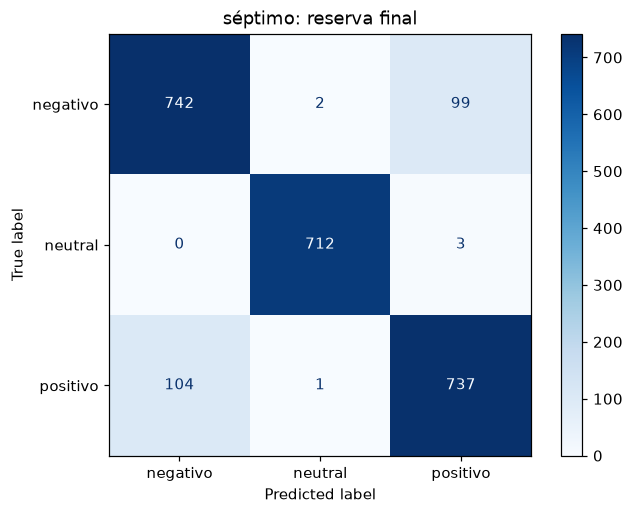

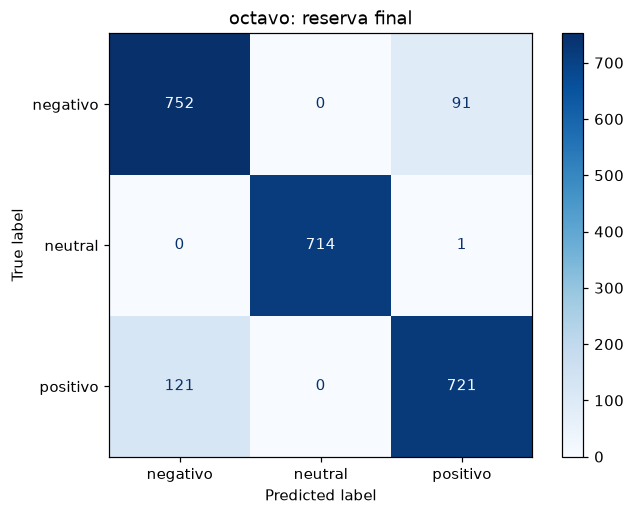

In [33]:
def intervalo_accuracy(correctos, total, z=1.96):
    proporcion = correctos / total
    denominador = 1 + z ** 2 / total
    centro = (proporcion + z ** 2 / (2 * total)) / denominador
    margen = z * np.sqrt(
        proporcion * (1 - proporcion) / total + z ** 2 / (4 * total ** 2)
    ) / denominador
    return centro - margen, centro + margen

configuraciones_fijas = {
    "séptimo": (pipeline_ensemble, resultados_ensemble["test_score"].mean()),
    "octavo": (pipeline_contextual, resultados_contextual["test_accuracy"].mean()),
}
evaluaciones_finales = []
modelos_reserva = {}
predicciones_reserva = {}
with threadpool_limits(limits=2):
    for nombre, (configuracion, accuracy_cv) in configuraciones_fijas.items():
        inicio = time.perf_counter()
        estimador = clone(configuracion).fit(X_train, y_train)
        prediccion = estimador.predict(X_valid)
        inferior, superior = intervalo_accuracy((prediccion == y_valid).sum(), len(y_valid))
        evaluaciones_finales.append({
            "modelo": nombre,
            "accuracy entrenamiento": accuracy_score(y_train, estimador.predict(X_train)),
            "accuracy CV": accuracy_cv,
            "accuracy reserva": accuracy_score(y_valid, prediccion),
            "F1 macro reserva": f1_score(y_valid, prediccion, average="macro"),
            "IC 95 % inferior": inferior,
            "IC 95 % superior": superior,
            "segundos ajuste y predicción": time.perf_counter() - inicio,
        })
        modelos_reserva[nombre] = estimador
        predicciones_reserva[nombre] = prediccion

resumen_reserva = pd.DataFrame(evaluaciones_finales).set_index("modelo")
display(resumen_reserva.round(4))
for nombre, prediccion in predicciones_reserva.items():
    print(f"\n{nombre.upper()}: reserva final")
    print(classification_report(y_valid, prediccion, digits=3))
    ConfusionMatrixDisplay.from_predictions(
        y_valid, prediccion, labels=["negativo", "neutral", "positivo"], cmap="Blues",
    )
    plt.title(f"{nombre}: reserva final")
    plt.show()


En reserva, el séptimo acertó **2.191 de 2.400** reseñas (91,292 %) y el octavo **2.187** (91,125 %). El octavo no confirmó aquí su pequeña ventaja de CV. Sus intervalos aproximados fueron 90,10-92,35 % y 89,92-92,20 %; la diferencia de cuatro reseñas no demuestra una mejora clara.

El séptimo obtuvo 97,51 % en entrenamiento y el octavo 92,64 %. El primero tiene una brecha mayor frente a CV y reserva, compatible con más sobreajuste; el segundo reduce esa brecha, pero no logró mejor accuracy en reserva. Entrenamiento alto por sí solo no significa mejor clasificación de textos nuevos.

El score público pertenece a otro conjunto y puede favorecer una configuración diferente. Para la entrega conservaremos el modelo del mejor envío público confirmado, como pide el enunciado. El octavo no lo reemplaza hasta conocer su resultado en Kaggle.


## Generación de submissions y modelo para entregar

Entrenamos copias de las ocho configuraciones con las 12.000 reseñas y generamos un CSV por modelo. Esto ocurre después de evaluar la reserva; esos modelos no se usan para calcular sus métricas.

Guardamos solo el modelo del mejor score público confirmado en `modelo_final.joblib`, junto al notebook. Este archivo adicional sí es obligatorio para Bloque Neón. No creamos una carpeta de modelos ni archivos de código externos.

Después de subir el octavo, anotaremos su score real en `scores_publicos` y ejecutaremos esta sección de nuevo. Si mejora el mejor score, se actualizará el modelo guardado; los CSV anteriores se conservan.


In [34]:
modelos_submission = {
    "submission_01_tfidf_logreg": pipeline,
    "submission_02_tfidf_bigramas_logreg": pipeline_bigramas,
    "submission_03_tfidf_completo_ultima_oracion_logreg": pipeline_ultima_oracion,
    "submission_04_tfidf_bloques_svm": pipeline_svm_bloques,
    "submission_05_estructural_hgb": pipeline_estructural,
    "submission_06_estructural_robusto_hgb": pipeline_gramatical,
    "submission_07_ensemble": pipeline_ensemble,
    "submission_08_stacking_contextual": pipeline_contextual,
}
scores_publicos = dict(zip(modelos_submission, [
    0.72333, 0.72777, 0.88000, 0.88444, 0.87333, 0.88666, 0.90000, None,
]))
nombre_modelo_final = max(
    (nombre for nombre, score in scores_publicos.items() if score is not None),
    key=lambda nombre: scores_publicos[nombre],
)

carpeta_envios = Path("submissions")
carpeta_envios.mkdir(exist_ok=True)
plantilla = pd.read_csv("sample_submission.csv")
archivos_generados = []

for nombre, configuracion in modelos_submission.items():
    modelo_envio = clone(configuracion)
    with threadpool_limits(limits=2):
        modelo_envio.fit(train["text"], train["label"])
        respuestas = modelo_envio.predict(eval_df["text"])

    submission = pd.DataFrame({"id": eval_df["id"], "answer": respuestas})
    assert list(submission.columns) == list(plantilla.columns) == ["id", "answer"]
    assert len(submission) == len(eval_df) == len(plantilla)
    assert submission["id"].tolist() == plantilla["id"].tolist()
    assert submission["id"].is_unique
    assert not submission.isna().any().any()
    assert submission["answer"].isin(["positivo", "negativo", "neutral"]).all()

    ruta_envio = carpeta_envios / f"{nombre}.csv"
    submission.to_csv(ruta_envio, index=False)
    archivos_generados.append({
        "archivo": ruta_envio.name, "filas": len(submission),
        "score público confirmado": scores_publicos[nombre],
        "ruta": str(ruta_envio.resolve()),
    })
    if nombre == nombre_modelo_final:
        paquete_modelo = {
            "modelo": modelo_envio,
            "nombre": nombre,
            "score_publico": scores_publicos[nombre],
            "versiones": versiones,
            "huellas_datos": huellas_datos,
            "semilla": RANDOM_STATE,
        }
        joblib.dump(paquete_modelo, "modelo_final.joblib", compress=3)

display(pd.DataFrame(archivos_generados))
print("Modelo guardado:", nombre_modelo_final)
print("Ruta:", Path("modelo_final.joblib").resolve())


Modelo guardado: submission_07_ensemble
Ruta: /Users/josefonseca/Desktop/Andes/Onceavo Semestre/Machine Learning/ISIS-2611-Proyecto-Parte-1/modelo_final.joblib


,archivo,filas,score público confirmado,ruta
0,submission_01_tfidf_logreg.csv,3000,0.72333,/Users/josefonseca/Desktop/Andes/Onceavo Semestre/Machine Learning/ISIS-2611-Proyecto-Parte-1/submissions/submission_01_tfidf_logreg.csv
1,submission_02_tfidf_bigramas_logreg.csv,3000,0.72777,/Users/josefonseca/Desktop/Andes/Onceavo Semestre/Machine Learning/ISIS-2611-Proyecto-Parte-1/submissions/submission_02_tfidf_bigramas_logreg.csv
2,submission_03_tfidf_completo_ultima_oracion_logreg.csv,3000,0.88000,/Users/josefonseca/Desktop/Andes/Onceavo Semestre/Machine Learning/ISIS-2611-Proyecto-Parte-1/submissions/submission_03_tfidf_completo_ultima_oracion_logreg.csv
3,submission_04_tfidf_bloques_svm.csv,3000,0.88444,/Users/josefonseca/Desktop/Andes/Onceavo Semestre/Machine Learning/ISIS-2611-Proyecto-Parte-1/submissions/submission_04_tfidf_bloques_svm.csv
4,submission_05_estructural_hgb.csv,3000,0.87333,/Users/josefonseca/Desktop/Andes/Onceavo Semestre/Machine Learning/ISIS-2611-Proyecto-Parte-1/submissions/submission_05_estructural_hgb.csv
5,submission_06_estructural_robusto_hgb.csv,3000,0.88666,/Users/josefonseca/Desktop/Andes/Onceavo Semestre/Machine Learning/ISIS-2611-Proyecto-Parte-1/submissions/submission_06_estructural_robusto_hgb.csv
6,submission_07_ensemble.csv,3000,0.90000,/Users/josefonseca/Desktop/Andes/Onceavo Semestre/Machine Learning/ISIS-2611-Proyecto-Parte-1/submissions/submission_07_ensemble.csv
7,submission_08_stacking_contextual.csv,3000,NaN,/Users/josefonseca/Desktop/Andes/Onceavo Semestre/Machine Learning/ISIS-2611-Proyecto-Parte-1/submissions/submission_08_stacking_contextual.csv


Los CSV se suben manualmente a Kaggle; generarlos no cuenta como participación. Guardar modelos de versiones anteriores no equivale a entregar varios modelos: `modelo_final.joblib` contiene únicamente la configuración con mejor score público confirmado.

Para Bloque Neón entregamos este notebook y ese archivo. Conservamos las salidas ejecutadas como evidencia del proceso. El resto de los CSV sirve para documentar la competencia.


### Comprobación del modelo guardado

Cargamos el archivo y comprobamos que reproduce exactamente el CSV ganador. En otra sesión deben ejecutarse primero los imports y las definiciones del notebook, porque el modelo incluye transformadores propios. No hace falta repetir la validación cruzada para cargarlo. Solo cargamos archivos joblib de confianza.


In [35]:
paquete_cargado = joblib.load("modelo_final.joblib")
modelo_final = paquete_cargado["modelo"]
with threadpool_limits(limits=2):
    predicciones_cargadas = modelo_final.predict(eval_df["text"])
envio_ganador = pd.read_csv(carpeta_envios / f"{paquete_cargado['nombre']}.csv")
assert np.array_equal(predicciones_cargadas, envio_ganador["answer"].to_numpy())
print("Modelo recargado: las 3.000 predicciones coinciden con el envío ganador.")


Modelo recargado: las 3.000 predicciones coinciden con el envío ganador.


## Cómo explicar el modelo final

1. El preprocesamiento unifica escritura y divide cada reseña en bloques. No elimina negaciones ni conectores.
2. TF-IDF combina frecuencia del término y rareza en entrenamiento, y normaliza cada vector. La regresión logística calcula un puntaje lineal por clase y lo convierte en probabilidades; ajusta pesos minimizando la pérdida de clasificación con regularización. C es inverso a la fuerza de regularización, no un porcentaje de confianza.
3. La SVM busca separar las clases con margen amplio; sus puntajes no son probabilidades. La calibración aprende una conversión sigmoide usando predicciones fuera de entrenamiento, antes de promediarlas.
4. El detector construye rasgos de opiniones y conectores. HistGradientBoosting agrega árboles que corrigen la pérdida del conjunto anterior mediante gradientes. Agrupa valores en intervalos para entrenar con eficiencia. La tasa 0.05 limita el aporte de cada árbol; hojas pequeñas y mínimos por hoja restringen la complejidad.
5. En stacking, el meta-modelo aprende de probabilidades obtenidas fuera del entrenamiento de cada clasificador base. No usamos sus predicciones de entrenamiento directo: serían demasiado optimistas.
6. El séptimo promedia las probabilidades del detector, stacking y SVM con pesos 50/30/20 y elige la clase de mayor valor. El octavo usa directamente stacking con contexto. El modelo entregado corresponde al mejor score público registrado, no automáticamente al último intento.

`min_df=2` para palabras y 3 para caracteres reduce términos raros. `max_iter=5000` en regresión logística es un límite del ajuste; las 200 o 300 iteraciones de boosting son etapas de árboles. Hojas pequeñas, mínimos por hoja y regularización limitan la complejidad. Estas elecciones mantienen un modelo manejable, pero no prueban que sea óptimo.


## Conclusiones y revisión de la rúbrica

Pasamos de 72,39 % local y 0.72333 público a 91,13 % local y 0.90000 público con el séptimo. El octavo subió a 91,33 % local; falta confirmar su score público. La posición de las opiniones ayudó mucho más que añadir bigramas por sí solos.

El modelo reconoce muy bien neutral, pero sigue confundiendo positivo y negativo cuando hay opiniones opuestas. Las expresiones están adaptadas a estas reseñas y no aseguran generalizar a otros productos o estilos. No usamos redes neuronales, embeddings preentrenados ni etiquetas de eval.

| Criterio | Evidencia o pendiente |
|---|---|
| Cinco o más envíos válidos | Siete scores públicos reportados; conservar el historial de Kaggle como evidencia. El octavo aún no cuenta. |
| Proceso de mejora | Registro de cambios, pruebas descartadas y comparación con las mismas particiones. |
| Organización y metodología | Calidad de datos, decisiones, pipelines, CV, análisis de errores y reserva final. |
| Comprensión y sustentación | Explicación del flujo, parámetros y limitaciones. Cada integrante debe poder defenderlo. |
| Resultados | Reportes por clase, matrices, intervalos y comparación local/pública. |
| Entregables replicables | Notebook ejecutado, versiones, huellas de los CSV y un modelo joblib comprobado. |
| Superar línea base | Pendiente: el score oficial no aparece en los documentos compartidos. No asumir que la meta 0.91 es la línea base. |
| Percentil | Pendiente de posición final en la competencia; el accuracy solo no determina este criterio. |

La rúbrica publicada en Bloque Neón y los porcentajes del enunciado no coinciden. Organizamos la evidencia para cubrir los criterios de ambos; confirmaremos con el curso cuál distribución de puntos aplica.

### Aportes individuales

| Integrante | Código | Aporte real por confirmar |
|---|---|---|
| Jose Manuel Fonseca | 202122456 | Por completar con el trabajo realizado. |
| Julian Pinto | Por completar | Por completar con el trabajo realizado. |
| Daniel Vergara | Por completar | Por completar con el trabajo realizado. |

Se usó IA como apoyo para proponer experimentos, revisar código y documentación. El equipo debe verificar los resultados y comprender las decisiones; este apoyo no reemplaza los aportes ni la sustentación.

### Material de apoyo

Prácticas del curso: P3 (procesamiento de textos), P7 (regresión logística), P8 (árboles) y P10 (Random Forest). TF-IDF y la ingeniería de características conectan con esos temas. Stacking, calibración e HistGradientBoosting son extensiones clásicas de scikit-learn; no aparecen implementados en esas prácticas y no los presentamos como ejercicios vistos allí.

Documentación oficial: [TF-IDF](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction), [stacking](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html), [HistGradientBoosting](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html) y [guardado de modelos](https://scikit-learn.org/stable/model_persistence.html). Conviene confirmar con el docente que las extensiones y los rasgos estructurales cumplen la interpretación de "técnicas abordadas" del requisito 4.1.
